In [ ]:
# CAP4770 Used Car Price Prediction Using Machine Learning
# by Josh Custodio & Josh White

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [89]:
df = pd.read_csv('used_car_price_dataset_extended.csv')

df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [90]:
print(df.shape)

df.info()

df.describe()

(10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [91]:
df.isnull().sum()

make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

In [92]:
df['service_history'] = df['service_history'].fillna('Unknown')

df['service_history'].isnull().sum()

np.int64(0)

In [93]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'fuel_type',
    'brand',
    'transmission',
    'color',
    'service_history',
    'insurance_valid'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,2,4,8587.64,1,1,5,2,0,0
1,2014,17.59,1500,2,4,5943.50,3,1,0,2,0,1
2,2023,18.09,2500,0,5,9273.58,0,0,0,0,1,1
3,2009,11.28,800,2,1,6836.24,4,1,1,0,0,1
4,2005,12.23,1000,2,2,4625.79,6,0,3,0,0,1


In [94]:
X = df.drop('price_usd', axis=1)

y = df['price_usd']

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [96]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [101]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

MAE: 1005.3800869850031
RMSE: 1317.7770580631761
R2: 0.7817193750519503


In [102]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [103]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 959.8301314500001
RMSE: 1220.9440463584135
R2: 0.8126201760064431


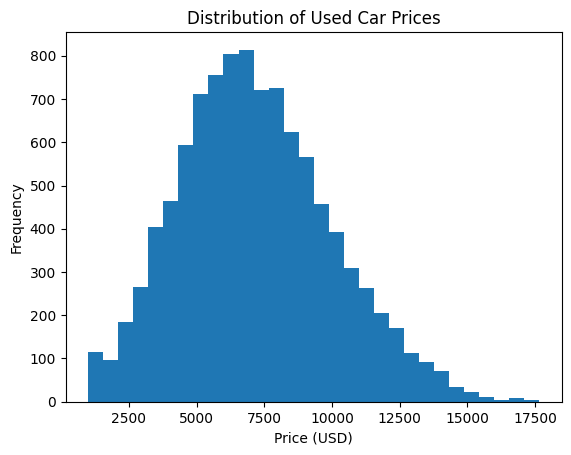

In [111]:
plt.hist(df['price_usd'], bins=30)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

In [121]:
avg_price_mileage = df.groupby('mileage_bin', observed=True)['price_usd'].mean()

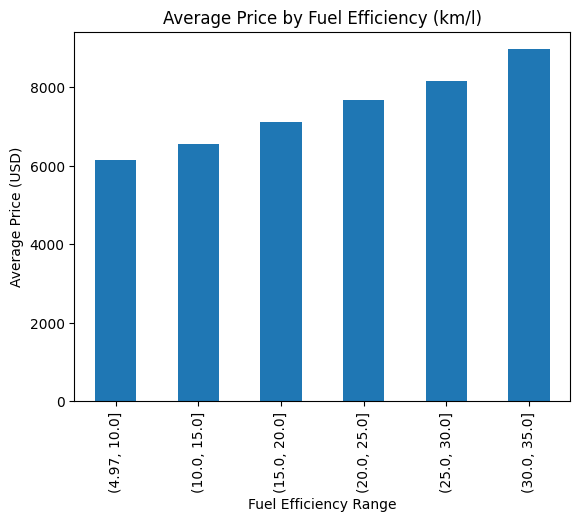

In [122]:
avg_price_mileage.plot(kind='bar')
plt.title('Average Price by Fuel Efficiency (km/l)')
plt.xlabel('Fuel Efficiency Range')
plt.ylabel('Average Price (USD)')
plt.show()

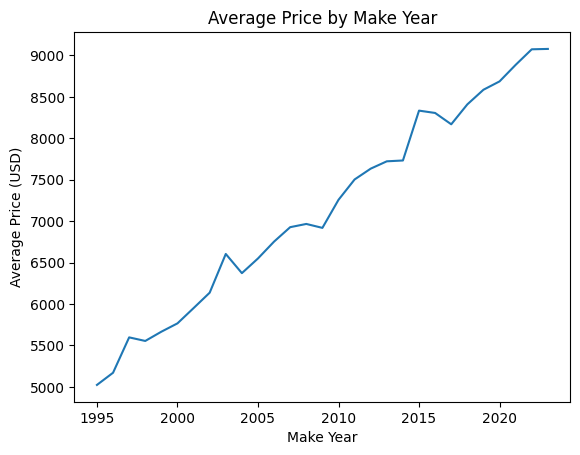

In [114]:
avg_price_year = df.groupby('make_year')['price_usd'].mean()
avg_price_year.plot()
plt.title('Average Price by Make Year')
plt.xlabel('Make Year')
plt.ylabel('Average Price (USD)')
plt.show()

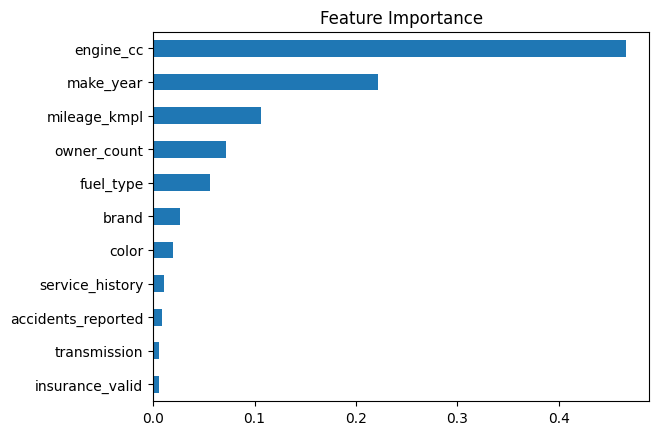

In [107]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

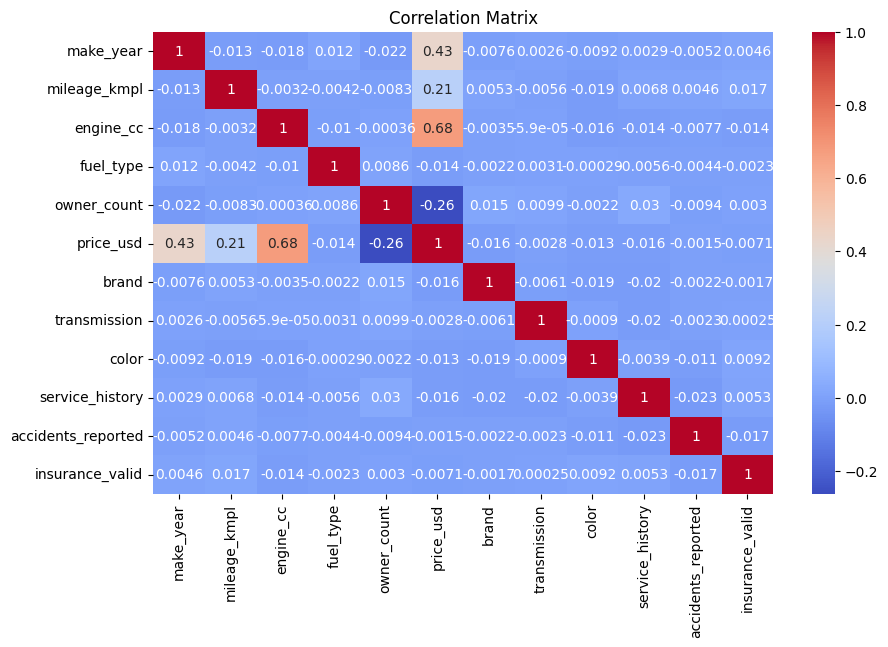

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [109]:
# Example prediction
sample_car = X_test.iloc[0:1]
predicted_price = rf.predict(sample_car)

print("Sample Input:\n", sample_car)
print("Predicted Price:", predicted_price[0])
print("Actual Price:", y_test.iloc[0])

Sample Input:
       make_year  mileage_kmpl  engine_cc  fuel_type  owner_count  brand  \
6252       2015         12.09       5000          0            1      6   

      transmission  color  service_history  accidents_reported  \
6252             0      5                0                   2   

      insurance_valid  
6252                0  
Predicted Price: 12354.695400000002
Actual Price: 12772.12
